# Расчет коэффициентов пролонгации за 2023 год

Этот ноутбук реализует требования ТЗ по пролонгациям:

- подготовка и очистка данных,
- расчет коэффициентов пролонгации 1-го и 2-го месяца,
- расчет по менеджерам и по отделу,
- расчет годовых взвешенных коэффициентов,
- экспорт результата в Excel-отчет.


## Шаг 1. Импорты и загрузка данных

Используем `prolongations.csv` как источник месяца завершения проекта и ответственного менеджера (`AM`), а `financial_data.csv` — как источник отгрузок.


In [9]:
from pathlib import Path
import pandas as pd

from build_prolongation_report import (
    parse_ru_month,
    build_project_month_agg,
    calculate_mart,
    monthly_kpi_for_group,
    yearly_weighted_kpi,
)

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR = BASE_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

prolongations = pd.read_csv(DATA_DIR / 'prolongations.csv')
financial = pd.read_csv(DATA_DIR / 'financial_data.csv')

print('prolongations shape:', prolongations.shape)
print('financial shape:', financial.shape)
prolongations.head()

prolongations shape: (477, 3)
financial shape: (451, 19)


,id,month,AM
0,42,ноябрь 2022,Васильев Артем Александрович
1,453,ноябрь 2022,Васильев Артем Александрович
2,548,ноябрь 2022,Михайлов Андрей Сергеевич
3,87,ноябрь 2022,Соколова Анастасия Викторовна
4,429,ноябрь 2022,Соколова Анастасия Викторовна


## Шаг 2. Очистка и построение проектной витрины

Ключевые правила ТЗ в логике:

- `стоп` / `end`: если встречается в последнем месяце реализации проекта или раньше, проект исключается из пролонгаций;
- `в ноль`: трактуется как 0, но для `last_month_shipment` берем предыдущий месяц **только если** в месяце завершения все части оплаты равны 0;
- дубликаты `id` суммируются по проекту и месяцу.


In [10]:
month_cols = [c for c in financial.columns if c not in {'id', 'Причина дубля', 'Account'}]
month_cols_sorted = sorted(month_cols, key=parse_ru_month)

month_agg = build_project_month_agg(financial, month_cols_sorted)
mart = calculate_mart(prolongations, month_agg, month_cols_sorted)

print('mart shape:', mart.shape)
mart.head()

mart shape: (477, 9)


,id,AM,completion_month_ts,completion_month,last_month_shipment,ship_t1,ship_t2,excluded_stop_end,used_prev_month_for_last
0,42,Васильев Артем Александрович,2022-11-01,Ноябрь 2022,36220.0,0.0,0.0,False,False
1,453,Васильев Артем Александрович,2022-11-01,Ноябрь 2022,0.0,39245.0,44320.0,False,False
2,548,Михайлов Андрей Сергеевич,2022-11-01,Ноябрь 2022,674000.0,674000.0,674000.0,False,False
3,87,Соколова Анастасия Викторовна,2022-11-01,Ноябрь 2022,70050.0,0.0,73380.0,False,False
4,429,Соколова Анастасия Викторовна,2022-11-01,Ноябрь 2022,30280.0,35580.0,35830.0,False,False


## Шаг 3. Расчет KPI по менеджерам и отделу

Для каждого отчетного месяца 2023 считаем:

- `coef_1m = numerator_1m / denominator_1m`, где
  - `denominator_1m`: сумма последнего месяца проектов, завершившихся в прошлом месяце,
  - `numerator_1m`: сумма отгрузок текущего месяца по тем же проектам, где есть пролонгация в 1-й месяц.

- `coef_2m = numerator_2m / denominator_2m`, где
  - база: проекты, завершившиеся 2 месяца назад и не пролонгированные в 1-й месяц,
  - `denominator_2m`: сумма последнего месяца этой базы,
  - `numerator_2m`: сумма отгрузок текущего месяца по проектам базы, пролонгированным во 2-й месяц.

Годовые коэффициенты считаются как взвешенные (отношение сумм), а не среднее месячных коэффициентов.


In [11]:
report_months = [pd.Timestamp(year=2023, month=m, day=1) for m in range(1, 13)]

manager_monthly_parts = []
manager_yearly_parts = []
for manager, g in mart.groupby('AM'):
    monthly = monthly_kpi_for_group(g, report_months)
    monthly.insert(0, 'AM', manager)
    manager_monthly_parts.append(monthly)
    manager_yearly_parts.append(yearly_weighted_kpi(monthly, group_name=manager, year=2023))

manager_monthly = pd.concat(manager_monthly_parts, ignore_index=True).sort_values(['AM', 'report_month'])
manager_yearly = pd.concat(manager_yearly_parts, ignore_index=True).rename(columns={'group': 'AM'}).sort_values('AM')

dep_monthly = monthly_kpi_for_group(mart, report_months)
dep_yearly = yearly_weighted_kpi(dep_monthly, group_name='Отдел', year=2023)

print('Managers monthly rows:', len(manager_monthly))
print('Managers yearly rows:', len(manager_yearly))
manager_yearly.head()

Managers monthly rows: 120
Managers yearly rows: 10


,AM,year,numerator_1m,denominator_1m,coef_1m_year,numerator_2m,denominator_2m,coef_2m_year
0,Васильев Артем Александрович,2023,6119964.43,11832147.79,0.517232,482441.58,5818845.40,0.08291
1,Иванова Мария Сергеевна,2023,1660095.55,4727657.16,0.351146,0.00,2503864.75,0.00000
2,Кузнецов Михаил Иванович,2023,470182.98,982724.44,0.478448,0.00,167675.00,0.00000
3,Михайлов Андрей Сергеевич,2023,2235422.29,3361833.59,0.664941,0.00,1056004.68,0.00000
4,Петрова Анна Дмитриевна,2023,109442.52,98492.00,1.111182,0.00,0.00,NaN


## Шаг 4. Экспорт итоговых артефактов

Сохраняем:

- промежуточные таблицы для проверки,
- финальный отчет в Excel для руководителя.


In [12]:
from build_prolongation_report import add_excel_visuals

mart.to_csv(OUT_DIR / 'project_mart.csv', index=False)
manager_monthly.to_csv(OUT_DIR / 'manager_monthly_kpi.csv', index=False)
manager_yearly.to_csv(OUT_DIR / 'manager_yearly_kpi.csv', index=False)
dep_monthly.to_csv(OUT_DIR / 'department_monthly_kpi.csv', index=False)
dep_yearly.to_csv(OUT_DIR / 'department_yearly_kpi.csv', index=False)

report_path = OUT_DIR / 'prolongation_report_2023.xlsx'
with pd.ExcelWriter(report_path, engine='openpyxl') as writer:
    manager_monthly.to_excel(writer, sheet_name='1_manager_kpi_monthly', index=False)
    manager_yearly.to_excel(writer, sheet_name='1_manager_kpi_yearly', index=False)
    dep_monthly.to_excel(writer, sheet_name='2_department_kpi', index=False)
    dep_yearly.to_excel(writer, sheet_name='2_department_yearly', index=False)

add_excel_visuals(report_path)

print('Saved report:', report_path)
print('Saved mart:', OUT_DIR / 'project_mart.csv')

Saved report: /Users/dmitrijpavlov/ds_git/junior_da_case/outputs/prolongation_report_2023.xlsx
Saved mart: /Users/dmitrijpavlov/ds_git/junior_da_case/outputs/project_mart.csv


## Шаг 5. Визуализация результатов
 
Добавляем интерактивные графики для быстрого анализа:
- Тренды коэффициентов по отделу
- Рейтинг менеджеров
- Распределение коэффициентов
- Heatmap по менеджерам и месяцам

/var/folders/5w/6pm9qpk95bv4lqd46z_j75kh0000gn/T/ipykernel_17310/2857929184.py:51: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitrijpavlov/ds_git/junior_da_case/.env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128260 (\N{ANTICLOCKWISE DOWNWARDS AND UPWARDS OPEN CIRCLE ARROWS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


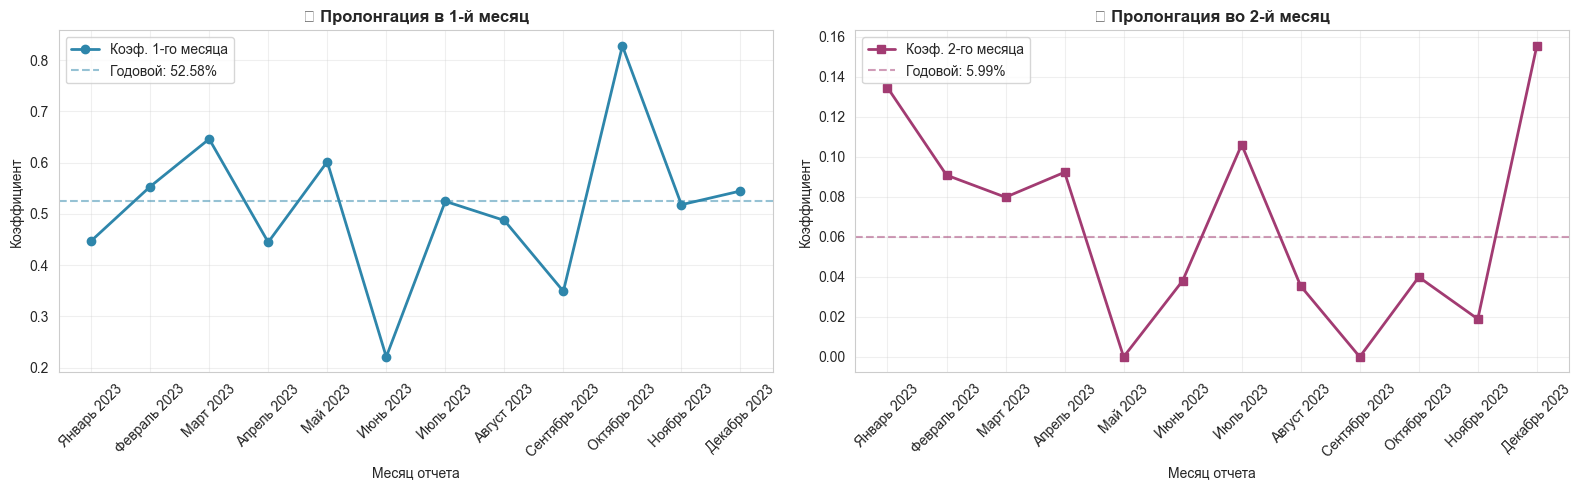

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["font.size"] = 10

# Тренд коэффициентов пролонгации по отделу
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# График 1: Коэффициент 1-го месяца
axes[0].plot(
    dep_monthly["report_month"], 
    dep_monthly["coef_1m"], 
    marker="o", 
    linewidth=2, 
    color="#2E86AB",
    label="Коэф. 1-го месяца"
)
axes[0].axhline(y=dep_yearly["coef_1m_year"].values[0], 
                color="#2E86AB", linestyle="--", alpha=0.5, 
                label=f"Годовой: {dep_yearly['coef_1m_year'].values[0]:.2%}")
axes[0].set_title("🔄 Пролонгация в 1-й месяц", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Месяц отчета")
axes[0].set_ylabel("Коэффициент")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].grid(alpha=0.3)

# График 2: Коэффициент 2-го месяца
axes[1].plot(
    dep_monthly["report_month"], 
    dep_monthly["coef_2m"], 
    marker="s", 
    linewidth=2, 
    color="#A23B72",
    label="Коэф. 2-го месяца"
)
axes[1].axhline(y=dep_yearly["coef_2m_year"].values[0], 
                color="#A23B72", linestyle="--", alpha=0.5,
                label=f"Годовой: {dep_yearly['coef_2m_year'].values[0]:.2%}")
axes[1].set_title("🔄 Пролонгация во 2-й месяц", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Месяц отчета")
axes[1].set_ylabel("Коэффициент")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

/var/folders/5w/6pm9qpk95bv4lqd46z_j75kh0000gn/T/ipykernel_17310/2830745587.py:30: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitrijpavlov/ds_git/junior_da_case/.env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


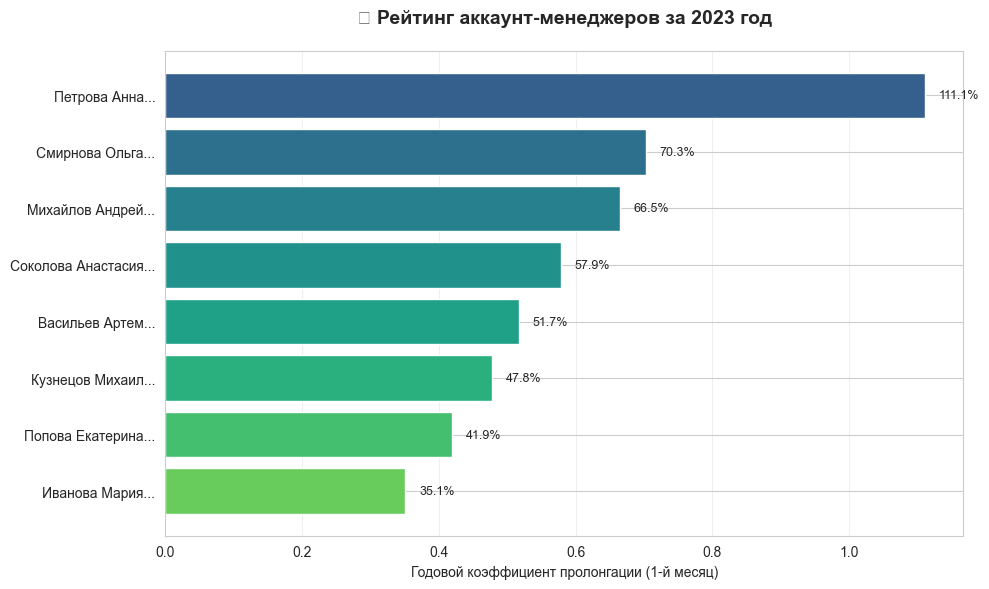

In [14]:
# Рейтинг менеджеров по годовому коэффициенту (1-й месяц)
manager_rating = (
    manager_yearly
    .sort_values("coef_1m_year", ascending=False)
    .reset_index(drop=True)
)

# Обрезаем имена для читаемости
manager_rating["AM_short"] = manager_rating["AM"].apply(
    lambda x: " ".join(x.split()[:2]) + "..." if len(x.split()) > 2 else x
)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    manager_rating["AM_short"], 
    manager_rating["coef_1m_year"], 
    color=plt.cm.viridis(np.linspace(0.3, 0.9, len(manager_rating)))
)

# Добавляем подписи значений
for bar, val in zip(bars, manager_rating["coef_1m_year"]):
    if not np.isnan(val):
        plt.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                f"{val:.1%}", va="center", fontsize=9)

plt.xlabel("Годовой коэффициент пролонгации (1-й месяц)")
plt.title("📊 Рейтинг аккаунт-менеджеров за 2023 год", fontsize=14, fontweight="bold", pad=20)
plt.gca().invert_yaxis()  # Лучший сверху
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/5w/6pm9qpk95bv4lqd46z_j75kh0000gn/T/ipykernel_17310/3896512548.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/5w/6pm9qpk95bv4lqd46z_j75kh0000gn/T/ipykernel_17310/3896512548.py:22: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitrijpavlov/ds_git/junior_da_case/.env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


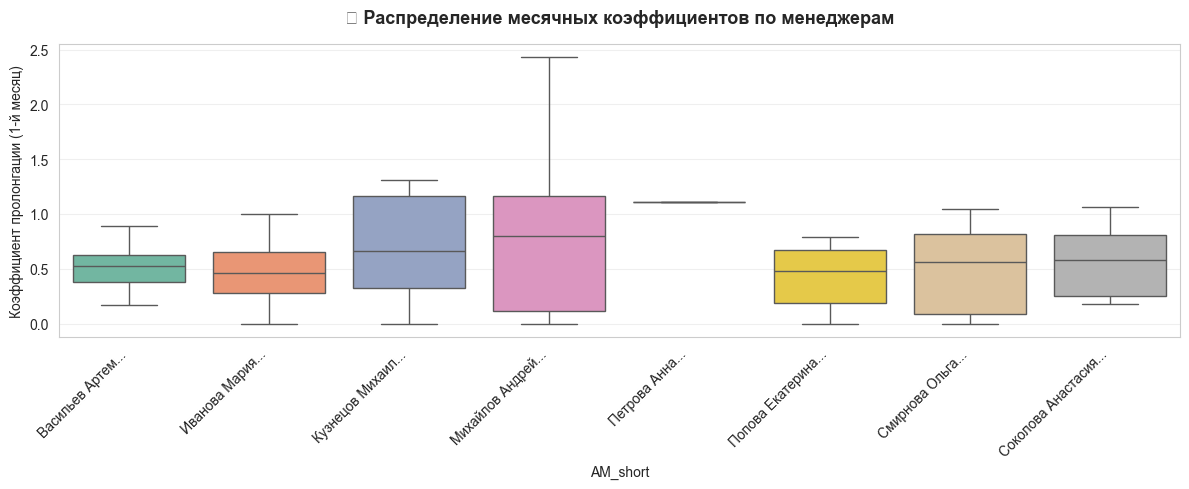

In [15]:
# Распределение коэффициентов по менеджерам (boxplot)
plt.figure(figsize=(12, 5))

# Подготовка данных
plot_data = manager_monthly[["AM", "coef_1m"]].dropna().copy()
plot_data["AM_short"] = plot_data["AM"].apply(
    lambda x: " ".join(x.split()[:2]) + "..." if len(x.split()) > 2 else x
)

sns.boxplot(
    data=plot_data, 
    x="AM_short", 
    y="coef_1m",
    palette="Set2",
    showfliers=False  # Скрываем выбросы для чистоты
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Коэффициент пролонгации (1-й месяц)")
plt.title("📦 Распределение месячных коэффициентов по менеджерам", fontsize=13, fontweight="bold", pad=15)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/5w/6pm9qpk95bv4lqd46z_j75kh0000gn/T/ipykernel_17310/4049111362.py:31: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/5w/6pm9qpk95bv4lqd46z_j75kh0000gn/T/ipykernel_17310/4049111362.py:31: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/dmitrijpavlov/ds_git/junior_da_case/.env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128467 (\N{SPIRAL CALENDAR PAD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/dmitrijpavlov/ds_git/junior_da_case/.env/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


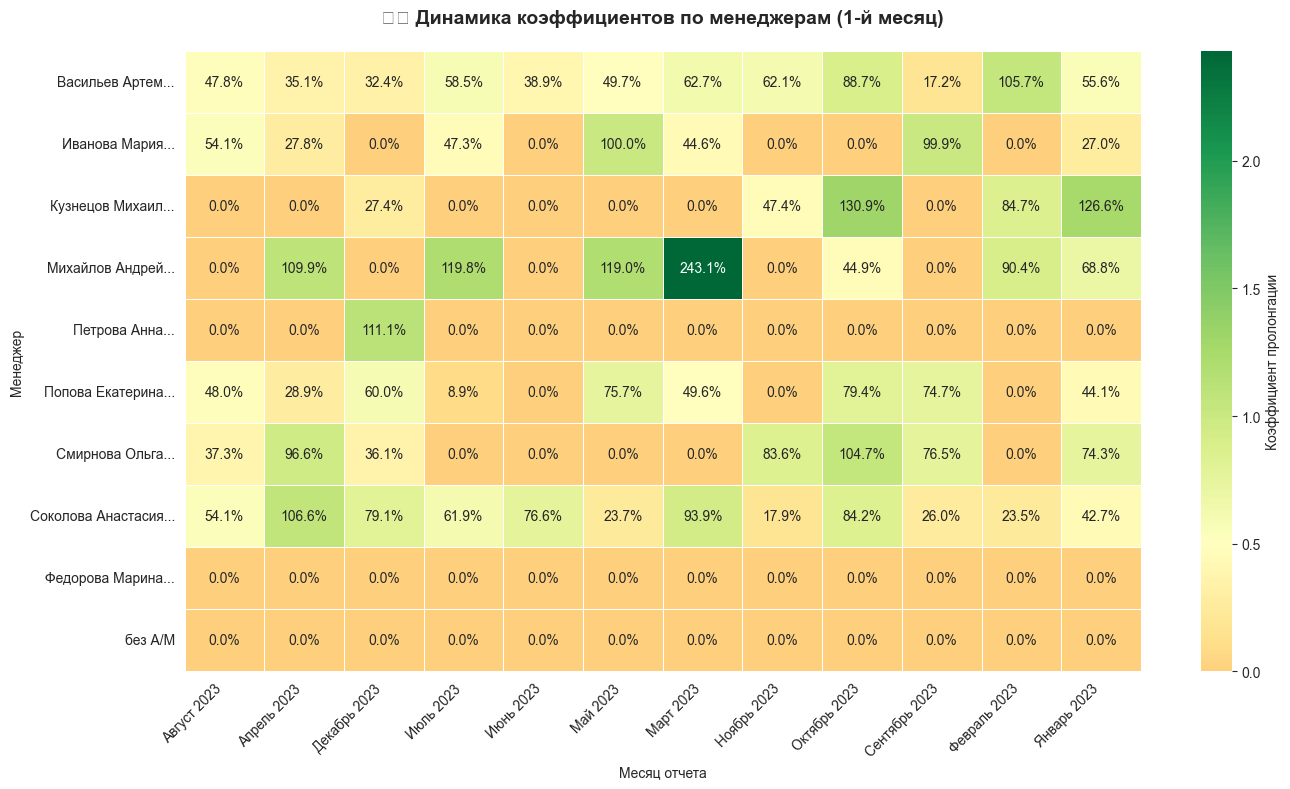

In [16]:
# Heatmap: коэффициенты по менеджерам и месяцам

# Пивот-таблица для heatmap
heatmap_data = (
    manager_monthly
    .pivot(index="AM", columns="report_month", values="coef_1m")
    .fillna(0)  # Заполняем пропуски нулями для визуализации
)

# Сокращаем имена для компактности
heatmap_data.index = heatmap_data.index.map(
    lambda x: " ".join(x.split()[:2]) + "..." if len(x.split()) > 2 else x
)

plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",  # Красный → Жёлтый → Зелёный
    center=0.5,
    cbar_kws={"label": "Коэффициент пролонгации"},
    linewidths=0.5
)

plt.title("🗓️ Динамика коэффициентов по менеджерам (1-й месяц)", 
          fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Месяц отчета")
plt.ylabel("Менеджер")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [17]:
print("🔍 Ключевые инсайты за 2023 год:\n")

# Лучший и худший менеджер по коэф. 1м
best_mgr = manager_yearly.loc[manager_yearly["coef_1m_year"].idxmax()]
worst_mgr = manager_yearly.loc[manager_yearly["coef_1m_year"].idxmin()]

print(f"✅ Лучший менеджер (1-й месяц): {best_mgr['AM']} — {best_mgr['coef_1m_year']:.1%}")
print(f"⚠️  Требует внимания: {worst_mgr['AM']} — {worst_mgr['coef_1m_year']:.1%}")
print()

# Средний по отделу
print(f"📊 Средний коэффициент по отделу (1-й месяц): {dep_yearly['coef_1m_year'].values[0]:.1%}")
print(f"📊 Средний коэффициент по отделу (2-й месяц): {dep_yearly['coef_2m_year'].values[0]:.1%}")
print()

# Месяц с лучшим результатом
best_month = dep_monthly.loc[dep_monthly["coef_1m"].idxmax()]
print(f"🎯 Лучший месяц для пролонгации: {best_month['report_month']} ({best_month['coef_1m']:.1%})")

🔍 Ключевые инсайты за 2023 год:

✅ Лучший менеджер (1-й месяц): Петрова Анна Дмитриевна — 111.1%
⚠️  Требует внимания: Иванова Мария Сергеевна — 35.1%

📊 Средний коэффициент по отделу (1-й месяц): 52.6%
📊 Средний коэффициент по отделу (2-й месяц): 6.0%

🎯 Лучший месяц для пролонгации: Октябрь 2023 (82.8%)
